In [22]:
# 1
import pandas as pd
df = pd.read_csv('../../data/historical_prices.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()
print(df)
df.info()

           Date     Open     High      Low    Close
0      12/14/22  4015.54  4053.76  3965.65  3995.32
1      12/13/22  4069.38  4100.96  3993.03  4019.65
2      12/12/22  3939.29  3990.71  3935.30  3990.56
3      12/09/22  3954.17  3977.02  3933.04  3934.38
4      12/08/22  3947.79  3974.19  3935.83  3963.51
...         ...      ...      ...      ...      ...
11331  01/09/78    90.64    91.52    90.01    90.64
11332  01/06/78    91.62    92.66    91.05    91.62
11333  01/05/78    92.74    94.53    92.51    92.74
11334  01/04/78    93.52    94.10    93.16    93.52
11335  01/03/78    93.82    95.15    93.49    93.82

[11336 rows x 5 columns]
<class 'pandas.DataFrame'>
RangeIndex: 11336 entries, 0 to 11335
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11336 non-null  str    
 1   Open    11336 non-null  float64
 2   High    11336 non-null  float64
 3   Low     11336 non-null  float64
 4   Close   11336 non-null  fl

In [23]:
# 2
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df = df.set_index('Date').sort_index(ascending=True)
df

,Open,High,Low,Close
Date,,,,
1978-01-03,93.82,95.15,93.49,93.82
1978-01-04,93.52,94.10,93.16,93.52
1978-01-05,92.74,94.53,92.51,92.74
1978-01-06,91.62,92.66,91.05,91.62
1978-01-09,90.64,91.52,90.01,90.64
...,...,...,...,...
2022-12-08,3947.79,3974.19,3935.83,3963.51
2022-12-09,3954.17,3977.02,3933.04,3934.38
2022-12-12,3939.29,3990.71,3935.30,3990.56


In [31]:
# 3
df['Range'] = df['High'] - df['Low']
df['Change'] = df['Close'] - df['Open']
df['Return'] = df['Change'] / df['Open'] * 100
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Volatility'] = df['Return'].rolling(20).std()
df

,Open,High,Low,Close,Range,Change,Return,MA20,MA50,Volatility
Date,,,,,,,,,,
1978-01-03,93.82,95.15,93.49,93.82,1.66,0.00,0.000000,NaN,NaN,NaN
1978-01-04,93.52,94.10,93.16,93.52,0.94,0.00,0.000000,NaN,NaN,NaN
1978-01-05,92.74,94.53,92.51,92.74,2.02,0.00,0.000000,NaN,NaN,NaN
1978-01-06,91.62,92.66,91.05,91.62,1.61,0.00,0.000000,NaN,NaN,NaN
1978-01-09,90.64,91.52,90.01,90.64,1.51,0.00,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-12-08,3947.79,3974.19,3935.83,3963.51,38.36,15.72,0.398197,3988.1675,3834.5244,1.114397
2022-12-09,3954.17,3977.02,3933.04,3934.38,43.98,-19.79,-0.500484,3987.0680,3840.4026,0.984608
2022-12-12,3939.29,3990.71,3935.30,3990.56,55.41,51.27,1.301504,3986.9495,3848.5014,1.012674


In [86]:
# 4
print(df['Close'].describe().loc[['count', 'mean', 'min', 'max', 'std', '50%']])
print('=====')
print('The day with the largest daily gain:', df['Change'].idxmax().strftime('%Y-%m-%d'))
print('The day with the largest daily loss:', df['Change'].idxmin().strftime('%Y-%m-%d'))
print('The day with the largest trading range:', df['Range'].idxmax().strftime('%Y-%m-%d'))

count    11336.000000
mean      1147.246819
min         86.900000
max       4796.560000
std       1032.680497
50%       1025.770000
Name: Close, dtype: float64
=====
The day with the largest daily gain: 2022-10-13
The day with the largest daily loss: 2020-03-12
The day with the largest trading range: 2020-03-13


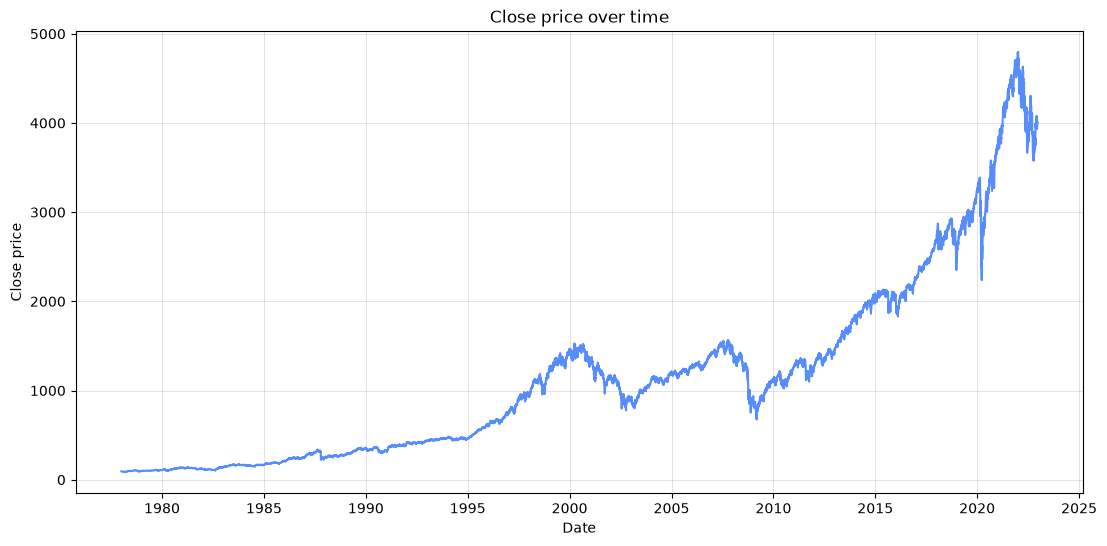

In [89]:
# 5
import matplotlib.pyplot as plt
plt.figure(figsize = (13,6))
plt.plot(df.index, df['Close'])
plt.xlabel('Date')
plt.ylabel('Close price')
plt.title('Close price over time')
plt.grid(True)
plt.show()

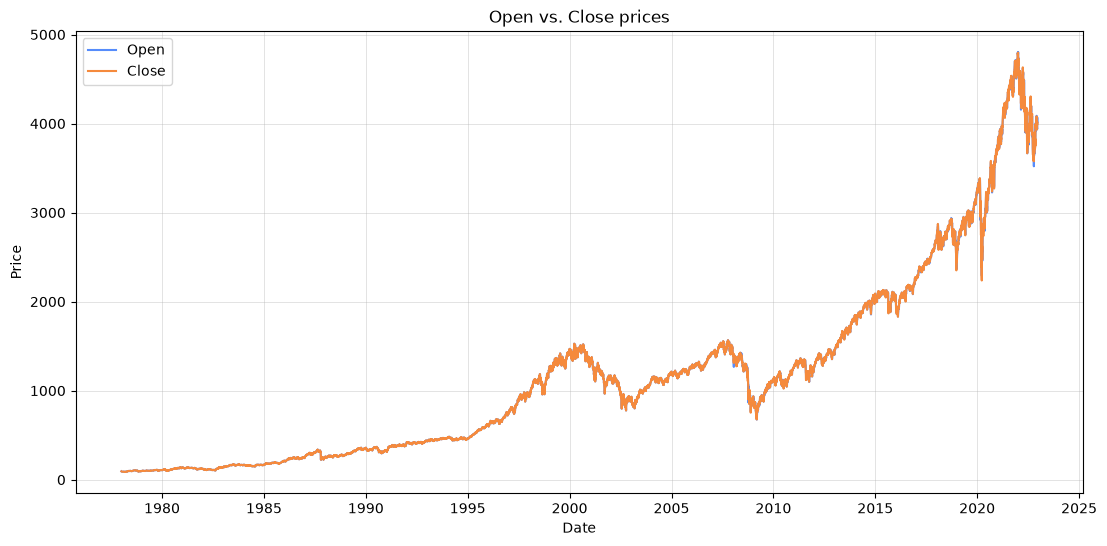

In [98]:
plt.figure(figsize = (13,6))
plt.plot(df.index, df['Open'], label='Open')
plt.plot(df.index, df['Close'], label='Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Open vs. Close prices')
plt.legend()
plt.grid(True)
plt.show()

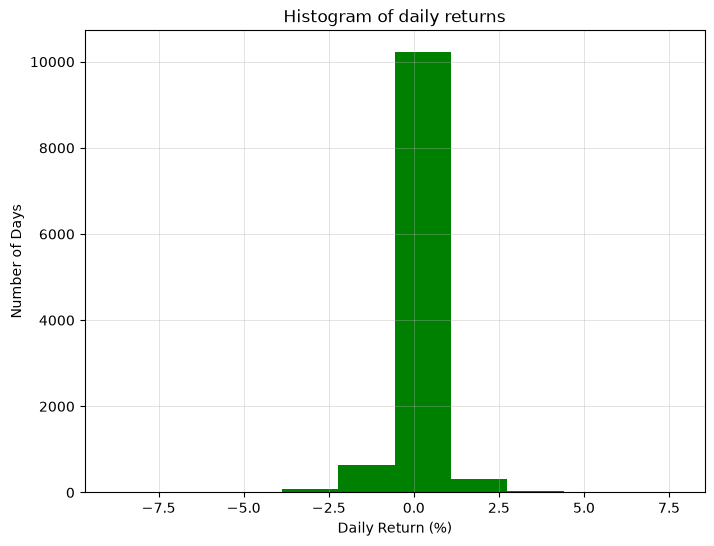

In [104]:
plt.figure(figsize = (8,6))
plt.hist(df['Return'].dropna(), bins = 10, color='green')
plt.xlabel('Return')
plt.ylabel('Number of Days')
plt.xlabel('Daily Return (%)')
plt.ylabel('Number of Days')
plt.title('Histogram of daily returns')
plt.grid(True)
plt.show()

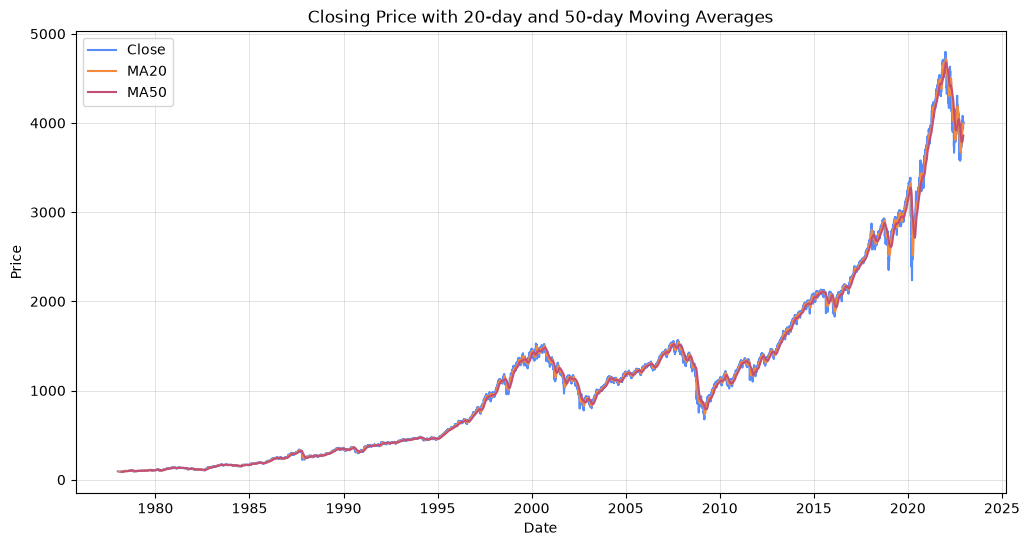

In [97]:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA20'], label='MA20')
plt.plot(df.index, df['MA50'], label='MA50')
plt.title('Closing Price with 20-day and 50-day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

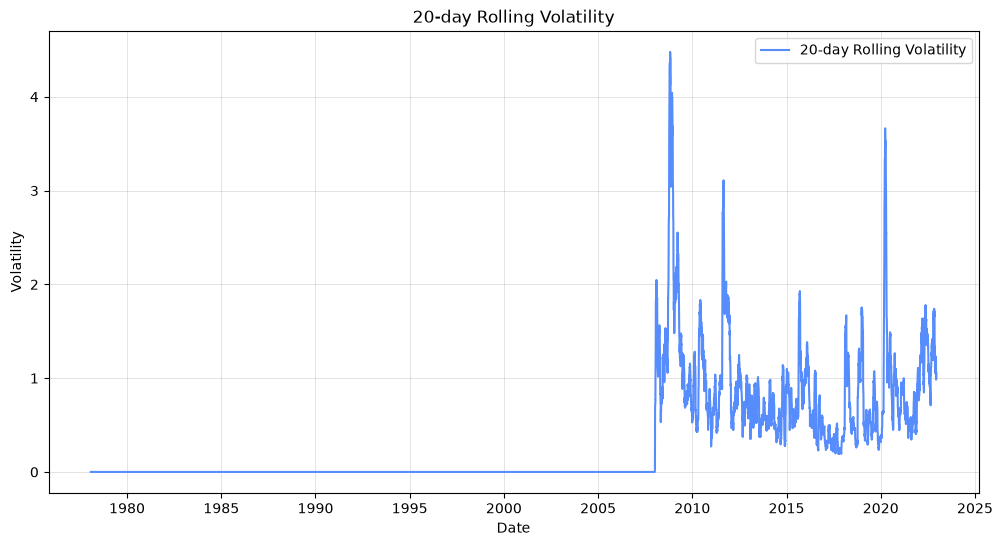

In [101]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volatility'], label='20-day Rolling Volatility')
plt.title('20-day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.legend()
plt.show()